[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_2/02C-Generalization.ipynb)

# 02C — Generalization
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 2, Notebook C — Hour 3**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

Every number reported in `02A` and `02B` was measured on the same data the model was fitted to.
The model marked its own homework, and it awarded itself good marks.

This notebook is about what happens when we stop letting it. The question turns out to govern
almost everything that follows in the course: it is the reason we hold data back, the reason
cross-validation exists, and the reason a published result can be entirely wrong without anybody
making an arithmetic mistake.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain why performance measured on the training data is not what we want to know;
- split data into training and test sets, and evaluate honestly;
- recognise underfitting and overfitting, and describe what each looks like;
- explain why a single train/test split gives a noisy answer;
- use k-fold cross-validation, and say what it buys;
- distinguish a validation set from a test set, and explain why both are needed;
- recognise **data leakage**, and use a pipeline to prevent the commonest form;
- make an analysis reproducible.

## Where this sits in the pipeline

`02A` opened with the course's ten-step pipeline and left three steps grey. This notebook is two of
them. Where a method notebook changes steps 7 and 8, this hour changes what the whole map is *for*:
without step 2 the numbers produced by every other step are not estimates of anything.

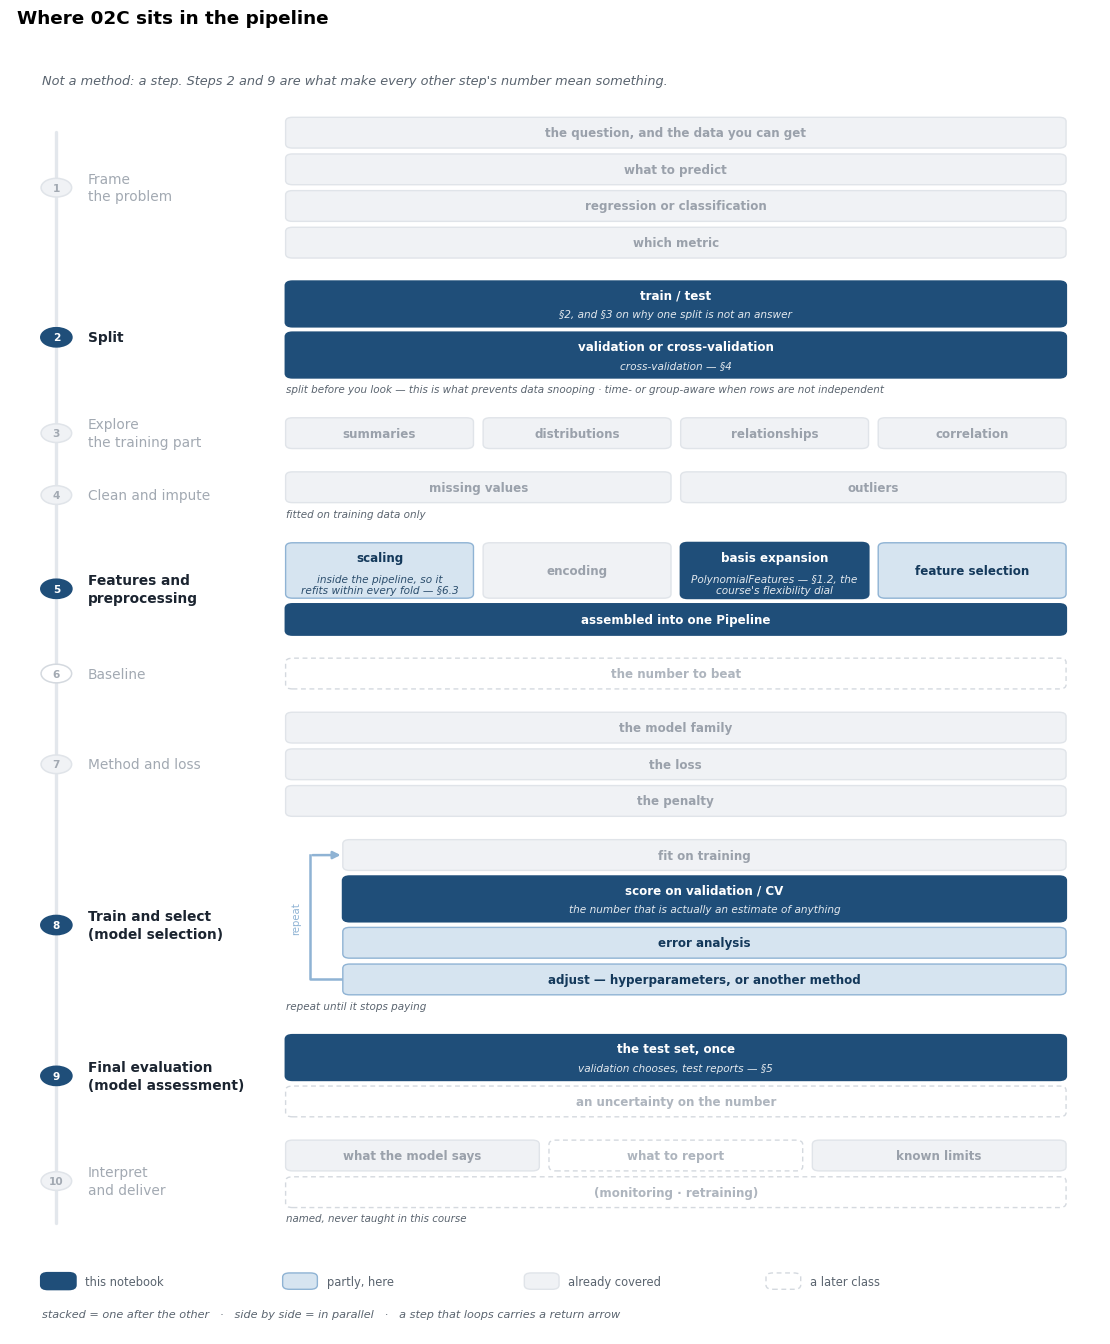

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2": "now", "3": "done", "4": "done", "5.1": "part", "5.3": "now",
     "5.4": "part", "7": "done", "8.1": "done", "8.2": "now", "8.3": "part", "8.4": "part",
     "9.1": "now", "10.1": "done", "10.3": "done",
     "5.after": "now",
     "5.2": "done"},
    notes={"2.1": "§2, and §3 on why one split is not an answer",
           "2.2": "cross-validation — §4",
           "5.3": "PolynomialFeatures — §1.2, the course's flexibility dial",
           "5.1": "inside the pipeline, so it refits within every fold — §6.3",
           "8.2": "the number that is actually an estimate of anything",
           "9.1": "validation chooses, test reports — §5"},
    title="Where 02C sits in the pipeline",
    lead="Not a method: a step. Steps 2 and 9 are what make every other step's number mean something.")
plt.show()

**The step worth remembering is 2, and its position.** It is second, above *explore*, above
*clean*, above *features* — everything below it happens on the training portion alone. Section 6
is an hour's worth of consequences of getting that order wrong.

# 1. Marking your own homework

We want to know how a model will perform on data it has not seen. That is the only thing that
matters scientifically: a model that only works on the flowers we already measured is of no use.

What we have measured so far is something different — how well the model reproduces the data it
was fitted to. Those two numbers can differ enormously, and the gap grows with the flexibility of
the model.

The clearest way to see this is with a model flexible enough to memorise.

## 1.1 A model that memorises

We generate 30 points from a smooth cubic relationship with noise added, and fit polynomials of
increasing degree. Recall from `02A` §10 that this is still linear regression: we simply construct
features $x, x^2, x^3, \dots$ and fit as usual.

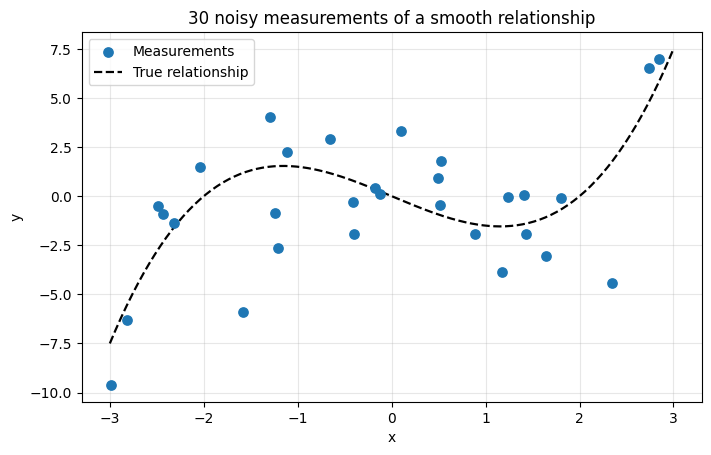

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(3)

n_points = 30
x = np.sort(rng.uniform(-3, 3, n_points))
def true_curve(t):
    return 0.5 * t**3 - 2 * t          # the relationship we are trying to recover
y = true_curve(x) + rng.normal(0, 2.5, n_points)   # what we actually measure

plt.figure(figsize=(8, 4.8))
plt.scatter(x, y, s=45, zorder=3, label="Measurements")
grid = np.linspace(-3, 3, 300)
plt.plot(grid, true_curve(grid), "k--", linewidth=1.6, label="True relationship")
plt.xlabel("x")
plt.ylabel("y")
plt.title("30 noisy measurements of a smooth relationship")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 1.2 Polynomial features, pipelines and hyperparameters

The next cells fit polynomials, and it is worth being clear about how, because the same device
returns throughout the notebook.

A polynomial of degree $d$,

$$
y \;=\; a_0 + a_1 x + a_2 x^2 + \cdots + a_d x^d
$$

is a curve in $x$, but it is **linear in the coefficients** $a_0, \dots, a_d$. So it can be fitted
by the ordinary least squares of `02A`, provided the single column $x$ is first expanded into $d$
columns $x, x^2, \dots, x^d$. Those columns are then treated as $d$ separate features.

That expansion is what `PolynomialFeatures(d)` does, and `LinearRegression` does the fitting. Two
steps, always performed in that order:

```
raw x  ->  PolynomialFeatures(d)  ->  x, x², …, x^d  ->  LinearRegression  ->  prediction
```

`make_pipeline` glues them into one object, so that `.fit` and `.predict` run the whole chain:

```python
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
```

This deserves more attention than a convenience wrapper, because from here on the pipeline — not
the estimator — is the unit that machine-learning code is written in.

The reason is that **a pipeline is itself a model**. It has `.fit` and `.predict` like any
estimator, so anything that accepts a model accepts a pipeline instead. When section 4 hands a
model to `cross_val_score`, or when Class 3 hands one to a hyperparameter search, a pipeline can be
handed over in its place and the preprocessing travels with it. What is fitted, evaluated and
eventually used is a single object, and "the model" then means the transformations as well as the
estimator on the end.

Two practical consequences follow immediately. The preprocessing can never fall out of step with
the model, because there is no way to apply one without the other. And the preprocessing is refitted
whenever the model is — which sounds like a detail, and is the subject of section 6, where it turns
out to decide whether an evaluation is honest.

Rather than take any of that on trust, the next two cells run each step on its own.

In [2]:
# scikit-learn always expects a 2-D array: one row per observation, one column per feature.
# Our x is a flat list of 30 numbers, so it has to be reshaped into a single column.
# The -1 means "work out this dimension from the length".
sample = np.array([-2.0, 0.5, 3.0]).reshape(-1, 1)

print("three values of x, shaped as one column:")
print(sample)
print("shape:", sample.shape, " -> 3 observations, 1 feature")

three values of x, shaped as one column:
[[-2. ]
 [ 0.5]
 [ 3. ]]
shape: (3, 1)  -> 3 observations, 1 feature


In [3]:
expander = PolynomialFeatures(3)
expanded = expander.fit_transform(sample)

print("the same three values after PolynomialFeatures(3):")
print("        1        x       x^2      x^3")
print(expanded.round(2))
print("shape:", expanded.shape, " -> 3 observations, 4 features")

the same three values after PolynomialFeatures(3):
        1        x       x^2      x^3
[[ 1.   -2.    4.   -8.  ]
 [ 1.    0.5   0.25  0.12]
 [ 1.    3.    9.   27.  ]]
shape: (3, 4)  -> 3 observations, 4 features


One column has become four: a constant column of ones, then $x$, $x^2$ and $x^3$. Check the middle
row — for $x = 0.5$ the entries are $1$, $0.5$, $0.25$ and $0.125$, which are exactly the powers.

From here `LinearRegression` has an ordinary multi-feature regression to solve, of the kind `02A`
already covered. It never learns that the columns are related; as far as it is concerned they are
four independent measurements.

`make_pipeline` stores the two objects in order and takes care of the handover.

In [4]:
demo_model = make_pipeline(PolynomialFeatures(3), LinearRegression())

print("the pipeline holds two named steps:")
for name, step in demo_model.steps:
    print(f"   {name:20} {step}")

demo_model.fit(x.reshape(-1, 1), y)
fitted = demo_model.named_steps["linearregression"]

print("\nafter fitting, the coefficients live in the second step:")
print("   coefficients of 1, x, x^2, x^3:", fitted.coef_.round(3))
print("   intercept:                     ", fitted.intercept_.round(3))

the pipeline holds two named steps:
   polynomialfeatures   PolynomialFeatures(degree=3)
   linearregression     LinearRegression()

after fitting, the coefficients live in the second step:
   coefficients of 1, x, x^2, x^3: [ 0.    -1.77  -0.058  0.466]
   intercept:                      -0.059


Two rules describe the whole object.

- `demo_model.fit(X, y)` passes `X` through `fit_transform` of every step except the last, then
  calls `fit` on the last with the transformed data.
- `demo_model.predict(X)` passes `X` through `transform` of every step except the last, then calls
  `predict` on the last.

So a single `.fit` expands the column *and* solves the regression, and a single `.predict` applies
the identical expansion before predicting. The two can never fall out of step, which is the real
reason for using a pipeline rather than calling the pieces by hand.

The coefficient of the constant column comes out as zero, because `LinearRegression` fits its own
intercept and a column of ones would duplicate it.

The other three estimate the coefficients of $x$, $x^2$ and $x^3$. The curve the data came from was
$0.5x^3 - 2x$, so the exact values are $-2$, $0$ and $0.5$:

| | $x$ | $x^2$ | $x^3$ |
|---|---|---|---|
| true | $-2$ | $0$ | $0.5$ |
| fitted | $-1.77$ | $-0.06$ | $0.47$ |

Close, but not exact — recovered from thirty noisy points, and that gap is what the rest of the
notebook is about.

> The degree is not learned from the data — we choose it before fitting. Quantities of that kind
> are called **hyperparameters**, and choosing them well is what most of this notebook is about.

The next cell fits polynomials of degree 1, 3 and 15 to **all thirty** points, and reports the
mean squared error of each — measured on those same thirty points.

1. Which degree will have the lowest error?
2. Roughly how low will the degree-15 error be?
3. Does a low error here mean the model is good?

**Think about your answer before running this cell.**

In [ ]:
for degree in [1, 3, 15]:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(x.reshape(-1, 1), y)
    error = mean_squared_error(y, model.predict(x.reshape(-1, 1)))
    print(f"degree {degree:>2}:  error on the data it was fitted to = {error:.3f}")

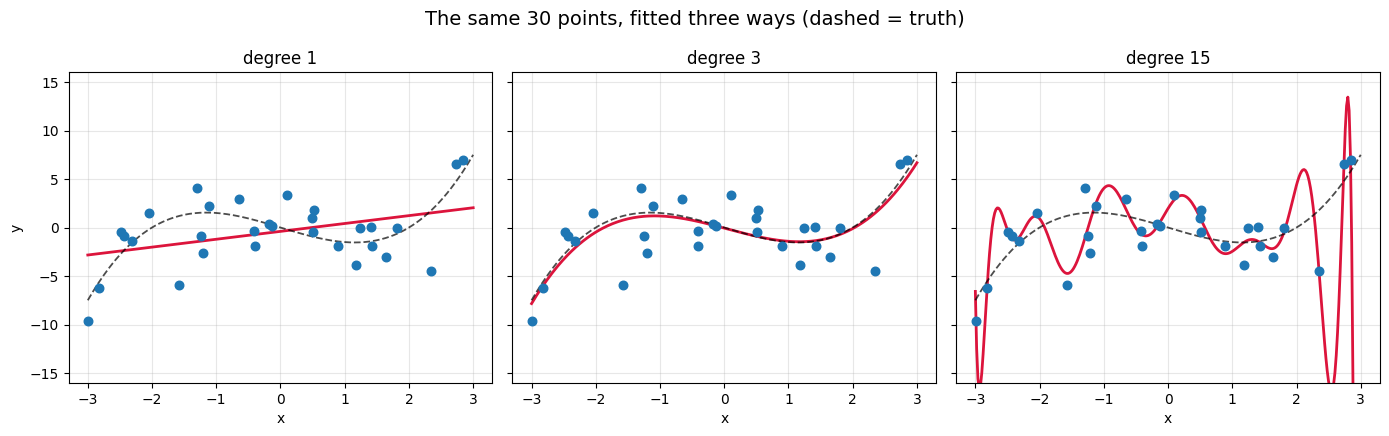

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)

for ax, degree in zip(axes, [1, 3, 15]):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(x.reshape(-1, 1), y)
    ax.scatter(x, y, s=38, zorder=3)
    ax.plot(grid, model.predict(grid.reshape(-1, 1)), color="crimson", linewidth=2)
    ax.plot(grid, true_curve(grid), "k--", linewidth=1.3, alpha=0.7)
    ax.set_title(f"degree {degree}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("y")
axes[0].set_ylim(-16, 16)
fig.suptitle("The same 30 points, fitted three ways (dashed = truth)", fontsize=14)
plt.tight_layout()
plt.show()

The degree-15 curve passes closer to the measurements than either of the others, and its error is
the smallest of the three: **1.92, against 6.19 for the cubic and 10.30 for the straight line**. By the only measure we have used so far, it is the best model.

It is obviously the worst. It swings violently between the points, and away from them it departs
from the true relationship entirely. It has not learned the relationship; it has memorised the
noise.

This has a name.

- **Underfitting**: the model is too rigid to represent the relationship. The degree-1 fit cannot
  bend, so it is wrong everywhere, and it is wrong on new data in the same way.
- **Overfitting**: the model is flexible enough to follow the noise as well as the signal. It fits
  the data it has seen and generalises badly.

The problem is that **training error cannot distinguish these**. It falls monotonically as the
model becomes more flexible, so it always prefers the most flexible model available.

# 2. Holding data back: training and test sets

The fix is simple to state. Before fitting anything, put some of the data aside. Fit on what
remains, and measure on the part the model has never seen.

- the **training set** is what the model is fitted to;
- the **test set** is used once, at the end, to estimate performance on new data.

`scikit-learn` provides `train_test_split` for exactly this. The `random_state` argument fixes
which points go where, so that the split can be reproduced — we return to that in §7.

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=0)

print(f"training points: {len(x_train)}")
print(f"test points:     {len(x_test)}")

training points: 18
test points:     12


Now the same three models, fitted only on the training points and scored on both.

In [8]:
print(f"{'degree':>7}{'train error':>14}{'test error':>14}")
for degree in [1, 2, 3, 5, 9, 15]:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x_train.reshape(-1, 1), y_train)
    train_error = mean_squared_error(y_train, model.predict(x_train.reshape(-1, 1)))
    test_error = mean_squared_error(y_test, model.predict(x_test.reshape(-1, 1)))
    print(f"{degree:>7}{train_error:>14.2f}{test_error:>14.2f}")

 degree   train error    test error
      1          9.37         13.52
      2          9.30         13.11
      3          5.17          9.17
      5          3.95          6.00
      9          3.48        162.96
     15          0.19   25995801.64


The two columns tell completely different stories.

The **training** error falls all the way down, as it must: more flexibility always fits the seen
data better. The **test** error falls at first, reaches a minimum, and then explodes. By degree 15
it is in the tens of millions — the model's predictions between the training points are wildly
wrong, and the test points fall between the training points.

This shape is the single most important picture in the notebook.

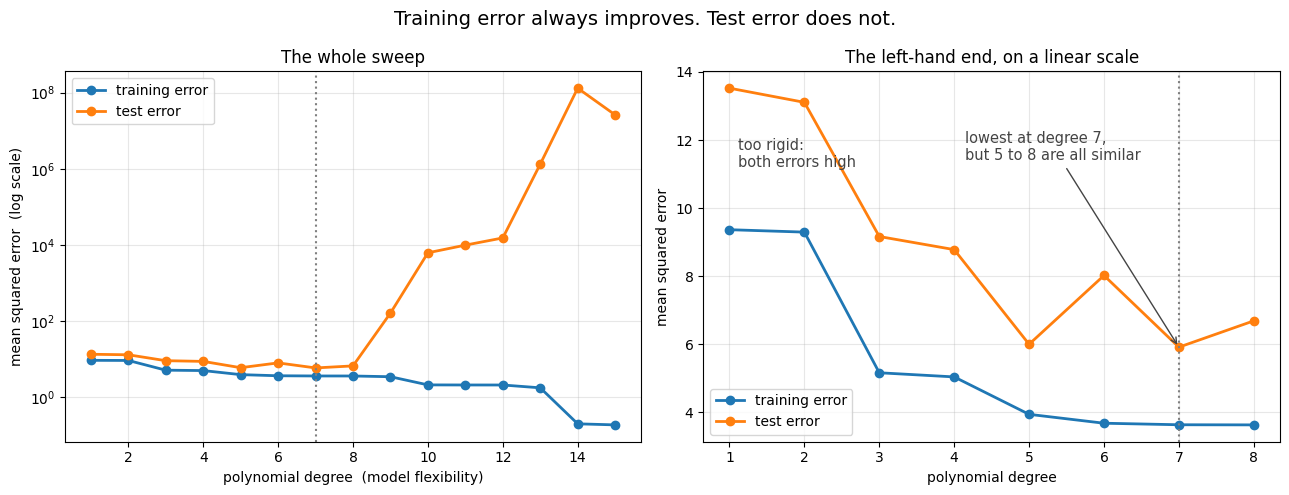

In [9]:
degrees = range(1, 16)
train_errors, test_errors = [], []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x_train.reshape(-1, 1), y_train)
    train_errors.append(mean_squared_error(y_train, model.predict(x_train.reshape(-1, 1))))
    test_errors.append(mean_squared_error(y_test, model.predict(x_test.reshape(-1, 1))))

best = int(np.argmin(test_errors)) + 1

fig, (full, zoom) = plt.subplots(1, 2, figsize=(13, 5))

# ---- the whole sweep, on a log scale so the explosion fits ----
full.plot(list(degrees), train_errors, marker="o", linewidth=2, label="training error")
full.plot(list(degrees), test_errors, marker="o", linewidth=2, label="test error")
full.axvline(best, color="grey", linestyle=":", linewidth=1.5)
full.set_yscale("log")
full.set_xlabel("polynomial degree  (model flexibility)")
full.set_ylabel("mean squared error  (log scale)")
full.set_title("The whole sweep")
full.grid(alpha=0.3)
full.legend()

# ---- the left-hand end, linear scale, where the minimum actually is ----
zoom_max = 8            # degree 9 onwards would squash everything else flat
zoom.plot(list(degrees)[:zoom_max], train_errors[:zoom_max], marker="o", linewidth=2, label="training error")
zoom.plot(list(degrees)[:zoom_max], test_errors[:zoom_max], marker="o", linewidth=2, label="test error")
zoom.axvline(best, color="grey", linestyle=":", linewidth=1.5)
zoom.annotate(f"lowest at degree {best},\nbut 5 to 8 are all similar", xy=(best, test_errors[best - 1]),
              xytext=(4.15, 11.4), fontsize=10.5, color="#444",
              arrowprops={"arrowstyle": "->", "color": "#444"})
zoom.text(1.12, 11.2, "too rigid:\nboth errors high", fontsize=10.5, color="#444")
zoom.set_xlabel("polynomial degree")
zoom.set_ylabel("mean squared error")
zoom.set_title("The left-hand end, on a linear scale")
zoom.grid(alpha=0.3)
zoom.legend()

fig.suptitle("Training error always improves. Test error does not.", fontsize=14)
plt.tight_layout()
plt.show()

On the left the model is too rigid and both errors are high: **underfitting**. On the right the
training error keeps falling while the test error climbs away from it: **overfitting**. The gap
between the two curves is a direct measure of how much the model has memorised.

Somewhere in between is the flexibility that suits this amount of data and this amount of noise.

Two things are worth noticing in the right-hand panel.

The best degree is not 3, even though the data were generated from a cubic. And the bottom of the
curve is **flat**: degrees 5 through 8 score between about 5.9 and 8.0, which on twelve test points
is no difference at all. Picking the single lowest and declaring it the right answer would be
reading far more into one split than it can support.

Both observations point the same way, and that is the subject of the next section.

<div class="alert alert-success">
<b>Mini-exercise 1 — Changing the amount of data</b><br>
Re-run the sweep with more data.
<br><br>
1. Regenerate <code>x</code> and <code>y</code> with <code>n_points = 200</code> instead of 30.<br>
2. Redo the split and the degree sweep, and plot the two curves again.<br>
3. Does the test error still explode at high degree? At which degree is it now lowest?<br>
4. What does this tell you about the relationship between how much data you have and how flexible a model you can afford?
</div>

In [10]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 3. One split is not an answer

Holding data back fixes the honesty problem. It introduces a new one: the answer now depends on
*which* points happened to land in the test set.

To see how much, we return to the classifier from `02B` — versicolor against virginica, using
petal length and width — and repeat the split forty times with different random states.

One argument in that call is new. `stratify=y_class` forces both halves to contain the two species
in the same proportion as the full dataset. Without it a random split can happen to place many more
of one species in the test set, which adds variation that has nothing to do with the model. For
classification, stratifying is almost always the right default.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
try:                                        # the fallback pattern of 01C 3.2
    iris = pd.read_csv(url)
except Exception:                           # no network: the copy bundled with scikit-learn
    from sklearn.datasets import load_iris
    bundled = load_iris(as_frame=True)
    iris = bundled.frame.rename(columns=lambda name: name.replace(" (cm)", "").replace(" ", "_"))
    iris["species"] = iris.pop("target").map(dict(enumerate(bundled.target_names)))
pair = iris[iris["species"].isin(["versicolor", "virginica"])]

X = pair[["petal_length", "petal_width"]]
y_class = (pair["species"] == "virginica").astype(int)

accuracies = []
for seed in range(40):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_class, test_size=0.3, random_state=seed, stratify=y_class)
    model = LogisticRegression().fit(X_tr, y_tr)
    accuracies.append(accuracy_score(y_te, model.predict(X_te)))

accuracies = np.array(accuracies)
print(f"lowest  test accuracy: {accuracies.min():.3f}")
print(f"highest test accuracy: {accuracies.max():.3f}")
print(f"mean:                  {accuracies.mean():.3f}   (spread {accuracies.max() - accuracies.min():.3f})")

lowest  test accuracy: 0.833
highest test accuracy: 1.000
mean:                  0.942   (spread 0.167)


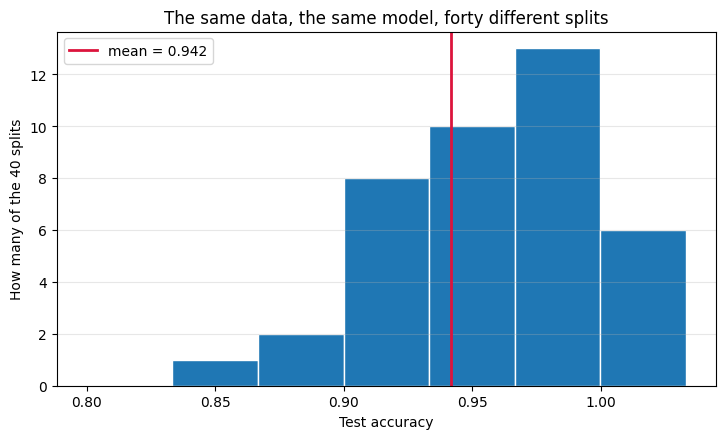

In [12]:
plt.figure(figsize=(8.5, 4.6))
plt.hist(accuracies, bins=np.arange(0.80, 1.045, 0.0333), edgecolor="white", color="tab:blue")
plt.axvline(accuracies.mean(), color="crimson", linewidth=2, label=f"mean = {accuracies.mean():.3f}")

plt.xlabel("Test accuracy")
plt.ylabel("How many of the 40 splits")
plt.title("The same data, the same model, forty different splits")
plt.grid(alpha=0.3, axis="y")
plt.legend()
plt.show()

Nothing changed between these runs except which thirty flowers were held out. Depending on the
split, an honest experimenter could have reported anything from about 0.83 to a perfect 1.000.

The spread corresponds to roughly five of the thirty test flowers. With a test set that small,
a single number carries a large uncertainty that is invisible unless you go looking for it.

> A single train/test split gives a noisy estimate. Reporting it as though it were exact is a common
> and serious overstatement.
>
> It is also, strictly, an estimate of the wrong thing. It is unbiased for a model fitted to the
> *training portion* — here 60% of the data — and the model you would actually deploy is fitted to
> all of it. More data usually means a better model, so the estimate tends to be **pessimistic**.
> Section 4's remark that larger $k$ gives "less pessimistic estimates" is the same observation from
> the other side.

# 4. Cross-validation

The fix is to average over splits instead of relying on one.

**k-fold cross-validation** divides the data into $k$ equal parts, called folds. Each fold takes a
turn as the test set while the other $k-1$ are used for training. That gives $k$ estimates, which
are then averaged.

Every point is used for testing exactly once, and for training $k-1$ times, so no data is wasted.

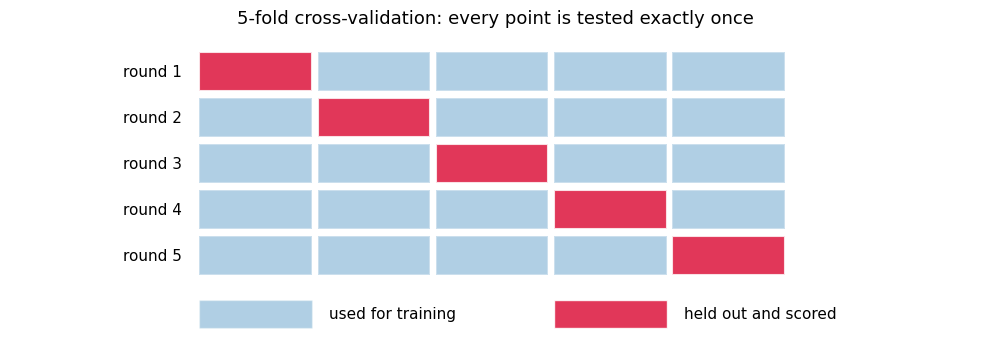

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.6))

k, n_blocks = 5, 5
for fold in range(k):
    for block in range(n_blocks):
        is_test = (block == fold)
        ax.add_patch(plt.Rectangle((block, k - 1 - fold), 0.95, 0.85,
                                   facecolor="crimson" if is_test else "tab:blue",
                                   alpha=0.85 if is_test else 0.35, edgecolor="white", linewidth=1.5))
    ax.text(-0.15, k - 1 - fold + 0.42, f"round {fold + 1}", ha="right", va="center", fontsize=11)

ax.add_patch(plt.Rectangle((0, -1.15), 0.95, 0.6, facecolor="tab:blue", alpha=0.35, edgecolor="white"))
ax.text(1.1, -0.85, "used for training", va="center", fontsize=11)
ax.add_patch(plt.Rectangle((3, -1.15), 0.95, 0.6, facecolor="crimson", alpha=0.85, edgecolor="white"))
ax.text(4.1, -0.85, "held out and scored", va="center", fontsize=11)

ax.set_xlim(-1.6, 6.6)
ax.set_ylim(-1.4, 5.3)
ax.set_title("5-fold cross-validation: every point is tested exactly once", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

`scikit-learn` performs the whole procedure in one call. `cross_val_score` takes an **unfitted**
model, the full data, and `cv=5` for the number of folds. It splits the data, fits a fresh copy of
the model on each training portion, scores that copy on the held-out fold, and returns the $k$
scores.

The model handed to it is never fitted itself; a new copy is fitted inside each fold. That is what
keeps the folds independent of one another.

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LogisticRegression(), X, y_class, cv=5)

print(f"the five fold scores: {scores.round(3)}")
print(f"mean:                 {scores.mean():.3f}")
print(f"standard deviation:   {scores.std():.3f}")

the five fold scores: [0.95 0.95 0.9  0.95 1.  ]
mean:                 0.950
standard deviation:   0.032


The mean is a far more stable estimate than any single split, and the standard deviation is itself
useful: it says how much the five folds disagreed with each other.

Resist the temptation to read it as the uncertainty on the mean, which is much smaller — on this
problem the folds scatter about six times more than the mean does across repeated partitions. There
is no unbiased estimator of that uncertainty for $k$-fold cross-validation, which is why the honest
thing to report is the one below: the mean, and the spread across folds, described as exactly
that.

Report both. "0.95" invites more confidence than the experiment supports; "0.95, with a spread of
0.03 across folds" is an honest summary.

**Choosing k.** Five and ten are the usual values. Larger $k$ means more training data in each
round and so less pessimistic estimates, at two costs rather than one: the model is fitted more
times, and the estimate itself becomes noisier. With $k$ large the training sets overlap almost
completely, so the fold scores are highly correlated and averaging them buys less than the count
suggests. With very
small datasets one can take $k = n$, fitting the model once per observation, which is called
leave-one-out.

<div class="alert alert-success">
<b>Mini-exercise 2 — Cross-validating the polynomials</b><br>
Use cross-validation instead of a single split for the polynomial sweep in section 2.
<br><br>
1. For each degree from 1 to 15, compute <code>cross_val_score</code> with <code>cv=5</code> and
   <code>scoring="neg_mean_squared_error"</code> on the full <code>x</code>, <code>y</code>.<br>
2. Plot the mean score against degree.<br>
3. Which degree is best now? Is it the same one the single split chose?<br>
4. Why does <code>scikit-learn</code> report a <em>negative</em> mean squared error?
</div>

In [15]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 5. Validation and test are different things

Section 2 used the test set to choose the polynomial degree. That was already a mistake.

The moment a number is used to make a decision, it stops being an unbiased estimate of future
performance. Having tried fifteen degrees and kept the one that scored best, we should expect the
winner's score to be optimistic: some of its advantage is genuine, and some is that it happened to
suit those particular test points.

The standard arrangement uses **three** parts.

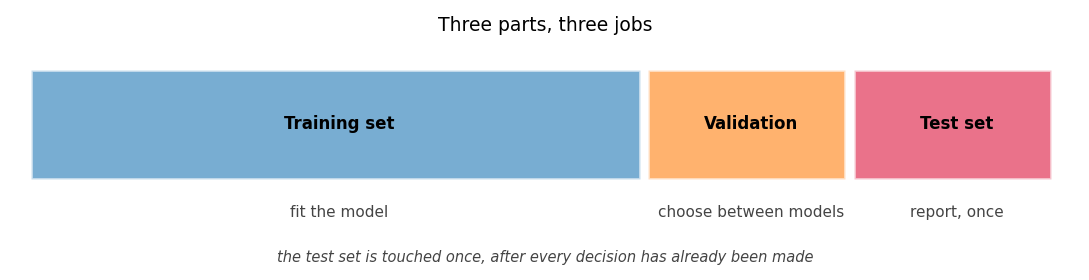

In [16]:
fig, ax = plt.subplots(figsize=(11, 2.9))

parts = [("Training set", 0.0, 0.60, "tab:blue",  "fit the model"),
         ("Validation",   0.60, 0.20, "tab:orange", "choose between models"),
         ("Test set",     0.80, 0.20, "crimson",  "report, once")]

for name, start, width, colour, purpose in parts:
    ax.add_patch(plt.Rectangle((start, 0.35), width - 0.008, 0.42,
                               facecolor=colour, alpha=0.6, edgecolor="white", linewidth=2))
    ax.text(start + width / 2, 0.56, name, ha="center", va="center", fontsize=12, fontweight="bold")
    ax.text(start + width / 2, 0.22, purpose, ha="center", va="center", fontsize=11, color="#444")

ax.text(0.5, 0.92, "Three parts, three jobs", ha="center", fontsize=13.5)
ax.text(0.5, 0.03, "the test set is touched once, after every decision has already been made",
        ha="center", fontsize=10.5, style="italic", color="#444")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1)
ax.axis("off")
plt.tight_layout()
plt.show()

- the **training set** fits the parameters;
- the **validation set** chooses between models — which degree, which method, which settings;
- the **test set** is looked at once, at the very end, to report a number.

If you look at the test set, adjust something, and look again, it has quietly become a validation
set and you no longer have an honest estimate.

In practice cross-validation usually replaces the separate validation set: it is run on the
training portion to make the choices, and a held-out test set is still kept aside for the final
report. That is the arrangement used for the rest of the course.

# 6. Data leakage

Everything so far assumes the split is honest — that nothing about the test data influenced the
model. **Data leakage** is the failure of that assumption, and it is the single most common reason
a published machine learning result turns out to be wrong.

It is dangerous because it does not look like an error. Nothing crashes. The code runs, the score
is excellent, and the excellence is entirely fictitious.

## 6.1 A demonstration on data with no signal at all

The following data are pure noise. The features are random numbers. The target is a random coin
flip, unrelated to the features by construction. **No model can do better than chance**, which is
0.5.

We then do something that sounds reasonable: because there are far more features than samples, we
first keep the 20 features most correlated with the target, and then cross-validate a classifier
on those.

The features are random. The target is random. They have nothing to do with each other.

1. What accuracy should an honest procedure report?
2. What do you think this procedure will report?

**Think about your answer before running this cell.**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

rng_leak = np.random.default_rng(1)
n_samples, n_features, n_keep = 100, 3000, 20

X_noise = rng_leak.normal(size=(n_samples, n_features))
y_noise = rng_leak.integers(0, 2, n_samples)        # unrelated to X_noise by construction

# Pick the most promising features using ALL the data, before any splitting.
correlations = np.array([abs(np.corrcoef(X_noise[:, j], y_noise)[0, 1]) for j in range(n_features)])
selected = np.argsort(correlations)[-n_keep:]

leaky_score = cross_val_score(LogisticRegression(max_iter=2000),
                              X_noise[:, selected], y_noise, cv=5).mean()

print(f"accuracy after selecting features on all the data: {leaky_score:.3f}")

Ninety per cent accuracy, on data containing no signal whatsoever.

The mechanism is worth being precise about. Among three thousand random features, some will be
correlated with the target **by chance**. Choosing the twenty best used the target values of every
sample — including the ones that later served as test data in each fold. By the time
cross-validation ran, the test points had already influenced which features it was allowed to see.

The fix is to make the selection part of what gets fitted, so that it happens inside each fold,
using only that fold's training data.

That needs the folds themselves, not merely their scores, so a bare `cross_val_score` is not enough
here. The loop below is written out so the mechanics are visible; in practice you would put the
selector into a pipeline, exactly as section 1.2 described, and hand that to `cross_val_score`
instead.
`KFold(n_splits=5, shuffle=True, random_state=0).split(X)` gives them: it yields, for each round, a
pair of **index arrays** — the row positions to train on, and the row positions to test on.
Indexing the data with those arrays produces that round's two halves.

In [18]:
honest_scores = []

for train_index, test_index in KFold(n_splits=5, shuffle=True, random_state=0).split(X_noise):
    # Select using the training half of THIS fold only.
    fold_correlations = np.array([abs(np.corrcoef(X_noise[train_index, j], y_noise[train_index])[0, 1])
                                  for j in range(n_features)])
    fold_selected = np.argsort(fold_correlations)[-n_keep:]

    model = LogisticRegression(max_iter=2000).fit(X_noise[train_index][:, fold_selected],
                                                  y_noise[train_index])
    honest_scores.append(accuracy_score(y_noise[test_index],
                                        model.predict(X_noise[test_index][:, fold_selected])))

print(f"selecting inside each fold: {np.mean(honest_scores):.3f}")
print(f"chance level:               0.500")

selecting inside each fold: 0.520
chance level:               0.500


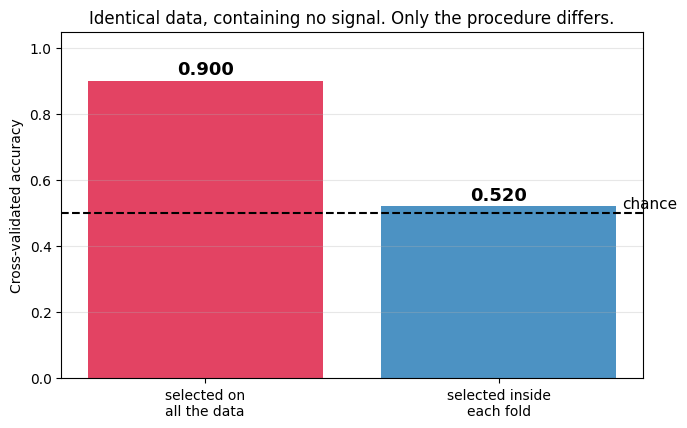

In [19]:
plt.figure(figsize=(7.5, 4.5))
bars = plt.bar(["selected on\nall the data", "selected inside\neach fold"],
               [leaky_score, np.mean(honest_scores)],
               color=["crimson", "tab:blue"], alpha=0.8)
plt.axhline(0.5, color="black", linestyle="--", linewidth=1.5)
plt.text(1.42, 0.515, "chance", fontsize=11)

for bar, value in zip(bars, [leaky_score, np.mean(honest_scores)]):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.02, f"{value:.3f}",
             ha="center", fontsize=13, fontweight="bold")

plt.ylabel("Cross-validated accuracy")
plt.title("Identical data, containing no signal. Only the procedure differs.")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3, axis="y")
plt.show()

Same data, same classifier, same cross-validation. The only difference is *when* the features were
chosen, and the reported accuracy moves from chance to ninety per cent.

## 6.2 The forms leakage takes

**Preprocessing fitted on all the data.** Standardising (rescaling a feature using its mean and
standard deviation), imputing (filling missing entries with, say, the column's mean), or applying
PCA each *learn* something from the data they are shown. Run before splitting, what they learn
includes the test data. This is the commonest form of leakage and the easiest to commit by
accident.

**Feature selection on all the data**, as above.

**Duplicate or near-duplicate rows.** If the same measurement appears twice and one copy lands in
each set, the model has seen the answer. Repeated measurements of the same patient, sample or
simulation are the usual culprits.

**Target leakage.** A feature that is a consequence of the target rather than a cause of it. A
model predicting whether a patient has a disease will do superbly if one of its features is the
dose of the drug used to treat that disease — and will be useless in the clinic, where the dose is
not yet known.

**Temporal leakage.** With data ordered in time, training on the future to predict the past. A
random split does exactly this. Time series need a split by time.

## 6.3 The fix: pipelines

A **pipeline** chains preprocessing and model into a single object. When that object is fitted, the
preprocessing is fitted too — on the training data only, and refitted from scratch inside every
cross-validation fold.

We have been using one since section 1: `make_pipeline(PolynomialFeatures(degree),
LinearRegression())`. There it saved a line of code. Here it is what makes the evaluation honest.

The example below uses `StandardScaler`, which has not appeared before. It replaces each feature by

$$
x' \;=\; \frac{x - \bar{x}}{s}
$$

where $\bar{x}$ and $s$ are that feature's mean and standard deviation. Every feature then has mean
0 and standard deviation 1, which puts features measured in different units — centimetres and
kilograms, say — on a comparable scale. You have already done this by hand in `01B` §11 using
broadcasting; `StandardScaler` is the same arithmetic, packaged so that it can be fitted once and
reapplied.

Whether it changes any answer depends on the method, and it is worth being clear that for
everything in `02A` and `02B` it very largely does not. Ordinary least squares is unaffected:
rescaling a feature rescales its coefficient and leaves every prediction identical. Scaling starts
to matter when the *size* of a coefficient means something, which is what regularization makes it
in Class 3, and when an algorithm takes steps through the parameter space, as gradient descent does
in Class 7. The two petal features here are already in the same units and of similar spread, so
standardising them changes little — which is convenient, because it lets the example below isolate
the thing this section is actually about: not whether to scale, but **where the scaler is fitted**.

The part that matters here is those two numbers: the scaler must **learn** $\bar{x}$ and $s$ from
data before it can transform anything. That is precisely what makes it able to leak.

In [20]:
from sklearn.preprocessing import StandardScaler

demo = StandardScaler().fit(X)
print("learned from the data — mean of each feature:", demo.mean_.round(3))
print("                        std of each feature: ", np.sqrt(demo.var_).round(3))

X_standardised = demo.transform(X)
print("\nafter transforming — mean of each feature:", X_standardised.mean(axis=0).round(3) + 0)
print("                     std of each feature: ", X_standardised.std(axis=0).round(3) + 0)

learned from the data — mean of each feature: [4.906 1.676]
                        std of each feature:  [0.821 0.423]

after transforming — mean of each feature: [0. 0.]
                     std of each feature:  [1. 1.]


Two numbers per feature, learned from whatever data the scaler is shown. Fit it on everything and
the test flowers have helped decide how the training flowers are rescaled.

The next cell does it both ways.

In [21]:
# WRONG: the scaler sees every value, including the test points, before splitting
scaler_first = StandardScaler().fit(X)
X_scaled_wrongly = scaler_first.transform(X)
wrong = cross_val_score(LogisticRegression(), X_scaled_wrongly, y_class, cv=5).mean()

# RIGHT: the scaler is refitted inside each fold, on that fold's training data only
correct = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression()),
                          X, y_class, cv=5).mean()

print(f"scaled before splitting (leaky):  {wrong:.4f}")
print(f"scaled inside a pipeline:         {correct:.4f}")

scaled before splitting (leaky):  0.9400
scaled inside a pipeline:         0.9400


Here the two agree almost exactly, and it is worth saying why rather than concluding that the
distinction does not matter.

Standardising uses only a mean and a standard deviation, computed from a hundred well-behaved
points. Whether the thirty test flowers are included barely moves those two numbers, so the leak
is real but tiny.

That is a property of this dataset, not a general rule. With a small sample, a heavy-tailed
distribution, or a preprocessing step that uses the target — feature selection, resampling, target
encoding — the same mistake produced the ninety per cent above.

> Put every step that learns anything from the data inside the pipeline. Then it cannot leak, and
> you do not have to reason case by case about whether it matters.

## 6.4 Splitting when the rows are not independent

Two of the leaks in the exercise above — the patient with three visits, and tomorrow's temperature
— have the same cause: `train_test_split` and `KFold` assume the rows can be shuffled freely, and
sometimes they cannot. Diagnosing that is most of the work, but `scikit-learn` has the two tools
that act on it, and they are one line each.

**Grouped data.** When several rows belong to the same subject, sample, patient or run, they must
stay on the same side of the split. `GroupKFold` takes a `groups` array saying which rows belong
together and guarantees that no group is split across folds.

**Ordered data.** When rows are ordered in time, the model must never be trained on the future and
tested on the past. `TimeSeriesSplit` produces folds that always train on a prefix and test on what
comes next, so the arrow of time is respected.

In [22]:
from sklearn.model_selection import GroupKFold, TimeSeriesSplit

# Ten measurements from four specimens: three visits for some, two for others.
specimen = np.array([0, 0, 0, 1, 1, 1, 2, 2, 3, 3])

print("GroupKFold — no specimen appears on both sides of a split:")
for fold, (train_rows, test_rows) in enumerate(GroupKFold(n_splits=2).split(specimen, groups=specimen), 1):
    print(f"   fold {fold}: train specimens {sorted(map(int, set(specimen[train_rows])))}"
          f"   test specimens {sorted(map(int, set(specimen[test_rows])))}")

print("\nTimeSeriesSplit — every test block lies after its training block:")
for fold, (train_rows, test_rows) in enumerate(TimeSeriesSplit(n_splits=3).split(np.arange(10)), 1):
    print(f"   fold {fold}: train rows {train_rows.min()}-{train_rows.max()}"
          f"   test rows {test_rows.min()}-{test_rows.max()}")

GroupKFold — no specimen appears on both sides of a split:
   fold 1: train specimens [0, 2]   test specimens [1, 3]
   fold 2: train specimens [1, 3]   test specimens [0, 2]

TimeSeriesSplit — every test block lies after its training block:
   fold 1: train rows 0-3   test rows 4-5
   fold 2: train rows 0-5   test rows 6-7
   fold 3: train rows 0-7   test rows 8-9


Read the second block carefully: the training set **grows** and the test block always sits after
it. That is deliberate. A model that will be used to predict next month should be validated the way
it will be used, and a random split would let it learn from next month to predict last month.

Both are drop-in replacements for the `cv=5` used throughout this notebook —
`cross_val_score(model, X, y, cv=GroupKFold(5), groups=specimen)`, or `cv=TimeSeriesSplit(5)`.

> There is no automatic check for this. Nothing in the data tells `scikit-learn` that two rows came
> from the same patient. **The grouping is something you know about your experiment and must
> supply**, and it is the single most common way a published result turns out to be optimistic.

<div class="alert alert-success">
<b>Mini-exercise 3 — Spot the leak</b><br>
For each procedure, say whether it leaks, and if so how:
<br><br>
1. Impute missing values with the column mean computed over the whole dataset, then split.<br>
2. Split, then impute the test set using the training set's column means.<br>
3. Remove duplicate rows, then split.<br>
4. Split a patient dataset randomly, when each patient contributed three separate visits.<br>
5. Predict tomorrow's temperature from a model trained on a random 70% of all days in the record.<br>
6. Standardise each feature using its own mean and standard deviation, then split.
</div>

In [23]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 7. Reproducibility

Every split, every shuffle and every random initialisation in this notebook depended on a random
number generator. Without a fixed seed, the numbers move on every run — and so do the conclusions.

Two conventions cover almost everything.

- `random_state=` on any `scikit-learn` function that shuffles or splits;
- a single generator created with `np.random.default_rng(seed)`, as introduced in `01B` §12, for
  data you generate yourself.

A result you cannot reproduce is not a result. If you report a number, you should be able to
produce it again on demand — and so should anyone reading you.

In [24]:
# Same seed, same split, every time.
first = train_test_split(X, y_class, test_size=0.3, random_state=42)[2].index[:5]
again = train_test_split(X, y_class, test_size=0.3, random_state=42)[2].index[:5]
other = train_test_split(X, y_class, test_size=0.3, random_state=7)[2].index[:5]

print(f"random_state=42, first five training rows: {list(first)}")
print(f"random_state=42, run again:                {list(again)}   <- identical")
print(f"random_state=7:                            {list(other)}   <- different")

random_state=42, first five training rows: [61, 97, 135, 78, 143]
random_state=42, run again:                [61, 97, 135, 78, 143]   <- identical
random_state=7:                            [115, 104, 77, 108, 83]   <- different


Fixing the seed does not make a result *correct*. It makes it *checkable*, which is the
precondition for anyone finding out whether it is correct.

It is also worth reporting results over several seeds when the spread matters — section 3 showed
how large that spread can be.

# 8. Common pitfalls

## 8.1 Reporting training performance

The number that matters is performance on unseen data. Training performance is an upper bound and
usually a loose one.

## 8.2 Reporting a single split as though it were exact

Section 3 showed a spread of 0.17 in accuracy across splits of the same data. Cross-validate, and
report the spread.

## 8.3 Choosing a model on the test set

Once the test set has informed a decision, it is a validation set. Keep a genuinely untouched set
for the final number.

## 8.4 Preprocessing before splitting

Scaling, imputing, selecting features or resampling on the full dataset leaks test information
into training. Use a pipeline.

## 8.5 Splitting randomly when the rows are not independent

Repeated measurements of the same subject, or data ordered in time, need a split that respects
that structure.

## 8.6 Trusting a result that seems too good

An unexpectedly excellent score is far more often a leak than a discovery. Ninety per cent on pure
noise looked entirely convincing.

## 8.7 Not fixing the seed

If the number changes when you re-run it, you do not yet know what the number is.

# 9. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — An honest evaluation of the 02B classifier</b><br>
In <code>02B</code> we reported 0.950 accuracy for the two-feature classifier, measured on the
data it was fitted to.
<br><br>
1. Split the data, fit on the training part only, and report the test accuracy.<br>
2. Cross-validate with <code>cv=5</code> and report the mean and standard deviation.<br>
3. How does the honest estimate compare with the 0.950 originally reported?<br>
4. Why is the gap here so much smaller than for the degree-15 polynomial?
</div>

In [25]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — How much data do you need?</b><br>
Investigate how the honest error depends on the amount of training data.
<br><br>
1. Generate 500 points from <code>true_curve</code> with the same noise.<br>
2. For training-set sizes of 10, 20, 50, 100, 200 and 400, fit a degree-9 polynomial and record the test error on a fixed held-out set.<br>
3. Plot test error against training-set size.<br>
4. At what size does the degree-9 model stop overfitting badly?<br>
5. Relate your answer to the dataset-size figure in <code>01A</code> §2.7.
</div>

In [26]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Build a leak, then fix it</b><br>
Construct your own example of leakage.
<br><br>
1. Generate 60 samples with 500 random features and a random binary target.<br>
2. Standardise the features and select the 10 with the largest absolute correlation with the target, using all the data.<br>
3. Cross-validate a logistic regression on those 10 features and record the accuracy.<br>
4. Now put the selection inside the folds, and record it again.<br>
5. Explain the difference to someone who has not taken this course, in three sentences.
</div>

In [27]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- The only performance worth reporting is performance on data the model has not seen.
- Training error falls monotonically with model flexibility, so it can never diagnose overfitting.
- Underfitting is too little flexibility; overfitting is enough flexibility to memorise the noise.
  The gap between training and test error measures how much has been memorised.
- A single train/test split is unbiased but noisy. The same data and model gave anything from 0.83
  to 1.00 depending on the split.
- Cross-validation averages over splits and costs nothing but computation. Report the spread as
  well as the mean.
- A validation set chooses; a test set reports. Once the test set informs a decision, it is no
  longer a test set.
- **Data leakage** is the commonest cause of results that are excellent and wrong. Selecting
  features on all the data gave 90% accuracy on data that contained no signal at all.
- Put every step that learns from the data inside a pipeline, and it cannot leak.
- Fix your seeds. A result that cannot be reproduced cannot be checked.

# Optional preparation for the next class

Before Class 3, students should be comfortable with:

- `train_test_split` and `cross_val_score`;
- the difference between training and test error, and what their gap means;
- why a validation set and a test set are not the same thing;
- recognising the commonest forms of leakage;
- building a `Pipeline` so that preprocessing cannot leak.

This notebook showed *that* flexibility must be controlled, and gave the machinery for measuring
when it is. Class 3 asks *why* the U-shaped curve has that shape — the **bias-variance tradeoff** —
and introduces **regularization**, a way of dialling flexibility down without having to change the
model.